# A0: Lattice Gas Cellular Automaton

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import gzip
from sys import getsizeof

## Simulation
### Initialization and Update Functions

In [ ]:
def initialize_lattice(L):
    """initialize a lattice of size LxL with half filled with ones and half with zeros

    Args:
        L (int): dimension of the lattice

    Returns:
        ndarray: initialized lattice of size LxL with half filled with ones and half with zeros
    """
    lattice = np.ones((L,L))
    lattice[:,:L//2] = 0
    return lattice

def choose_neighbor(row, col, L):
    """select a random neighbor of a site in a lattice of size LxL assuming
    periodic boundary conditions in the horizontal direction and 
    closed boundary conditions in the vertical direction

    Args:
        L (int): dimension of the lattice
        
    Returns:
        tuple: coordinates of the chosen neighbor
    """
    #   0
    # 2 x 3
    #   1
    # if at the top row, choose a random neighbor except the one above
    if row == 0:
        neighbor = np.random.choice([1,2,3])
    # if at the bottom row, choose a random neighbor except the one below
    elif row == L-1:
        neighbor = np.random.choice([0,2,3])
    # otherwise, choose a random neighbor
    else:
        neighbor = np.random.choice([0,1,2,3])
    if neighbor == 0:  # up
        n_row = row - 1
        n_col = col
    elif neighbor == 1:  # down
        n_row = row + 1
        n_col = col
    elif neighbor == 2:  # left
        n_row = row
        n_col = (col - 1) % L  # wrap around horizontally
    elif neighbor == 3:  # right
        n_row = row
        n_col = (col + 1) % L  # wrap around horizontally
    return n_row, n_col 

def update(lattice):
    """evolves the lattice by randomly selecting a site and swapping it with one of its neighbors

    Args:
        lattice (ndarray): current state of the lattice

    Returns:
        ndarray: new state of the lattice after one update
    """
    L = lattice.shape[0]
    # choose a random site
    row = np.random.randint(0,lattice.shape[0])
    col = np.random.randint(0,lattice.shape[1])
    # choose a random neighbor respecting the boundary conditions
    n_row, n_col = choose_neighbor(row, col, L)
    # store the current site and the neighbor
    site = lattice[row,col]
    neighbor = lattice[n_row, n_col]
    # swap the current site with the neighbor
    lattice[row][col] = neighbor
    lattice[n_row][n_col] = site
    return lattice

def sweep(lattice):
    """performs a sweep over the lattice, that is LxL updates
    
    Args:
        lattice (ndarray): current state of the lattice
        
    Returns:
        ndarray: new state of the lattice after LxL updates
    """
    L = lattice.shape[0]
    new_lattice = lattice.copy()
    for _ in range(L*L):
        new_latice = update(new_lattice)
    return new_lattice

### Running the Simulation

In [ ]:
L = 100  # size of the lattice
lattice = initialize_lattice(L)
snapshots = []
snapshots.append(lattice)
n_sweeps = 1500  # number of sweeps to perform
for i in range(n_sweeps):
    lattice = sweep(lattice)
    snapshots.append(lattice)

## Measurements

### Producing the Animation

In [185]:
from matplotlib import animation, rcParams
from IPython.display import HTML
from imageio_ffmpeg import get_ffmpeg_exe
rcParams['animation.ffmpeg_path'] = get_ffmpeg_exe()

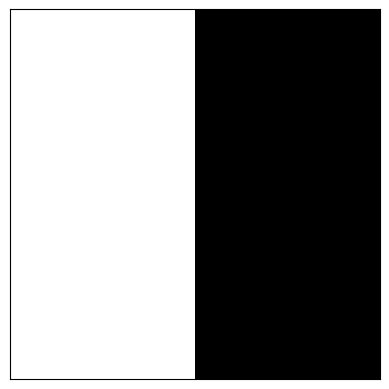

In [ ]:
animation_frames = snapshots[::5]
fig, ax = plt.subplots()
im = ax.imshow(animation_frames[0], cmap='gray_r')
ax.set_xticks([])
ax.set_yticks([])
def update_frame(n):
    im.set_array(animation_frames[n])
    return im,

In [188]:
anim = animation.FuncAnimation(fig, func=update_frame, frames=len(animation_frames), interval=50, blit=True)
HTML(anim.to_jshtml())

### Measuring the Entropy

In [125]:
sizes = []
for snap in snapshots:
    compressed_lattice = gzip.compress(snap.tobytes())
    size = getsizeof(compressed_lattice)
    sizes.append(size)

Text(0, 0.5, 'Compressed Size (bytes)')

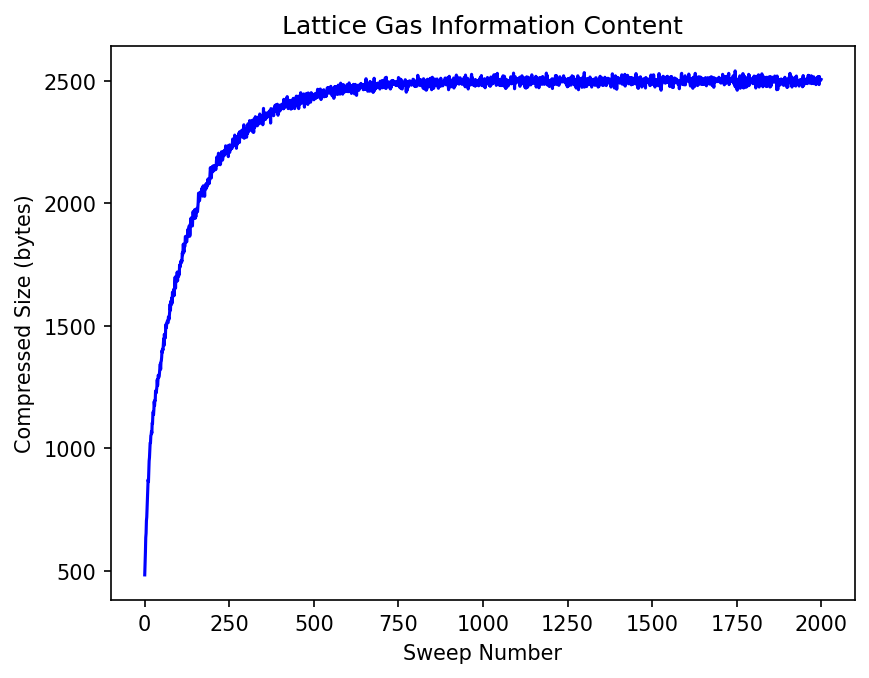

In [183]:
fig, ax = plt.subplots(dpi=150)
ax.plot(sizes, color='blue')
ax.set_title("Lattice Gas Information Content")
ax.set_xlabel("Sweep Number")
ax.set_ylabel("Compressed Size (bytes)")